In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score,accuracy_score, confusion_matrix
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
import shap


In [3]:
from scipy.io import arff
import pandas as pd

# Path to your file (relative path — IMPORTANT for grading)
path = "../data/raw/mammography.arff"

# Load ARFF file
data, meta = arff.loadarff(path)

# Convert to DataFrame
df = pd.DataFrame(data)

# Preview

df['class'] = df['class'].str.decode('utf-8')
df['class'] = df['class'].astype(int)
df['class'] = df['class'].replace(-1, 0)
df.to_csv("../data/processed/mammography.csv", index=False)
print("Saved successfully!")
df.head()

Saved successfully!


,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,0
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,0
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,0
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,0
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,0


In [5]:
print(df['class'].value_counts())
df = pd.read_csv("../data/processed/mammography.csv")
df.columns

class
0    10923
1      260
Name: count, dtype: int64


Index(['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6', 'class'], dtype='object')

##TASK 4 Visualize the univariate distribution of each continuos features 

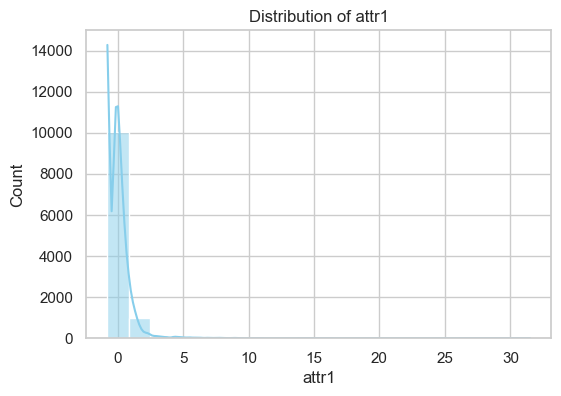

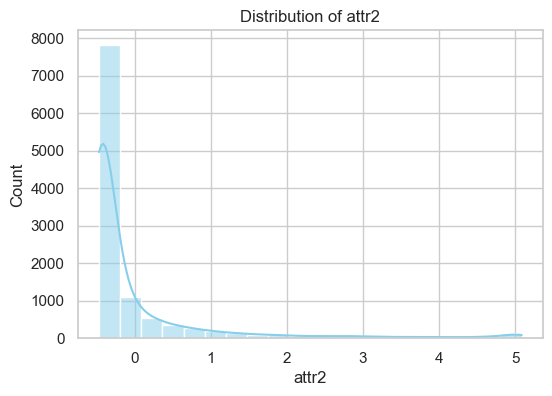

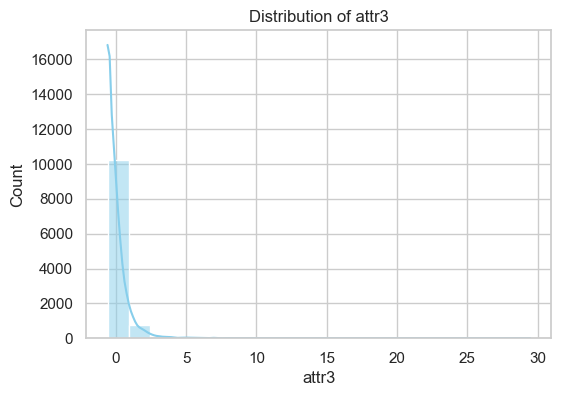

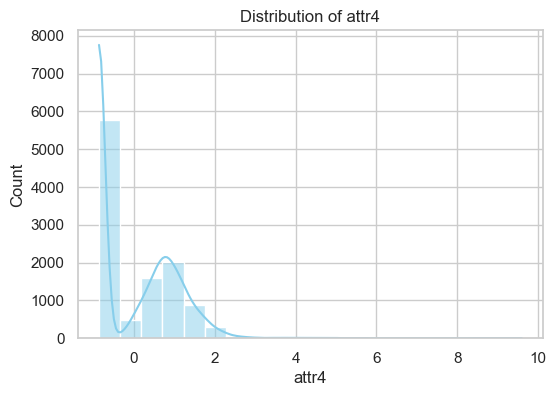

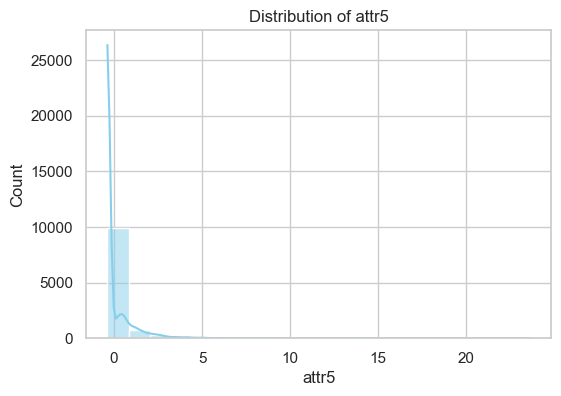

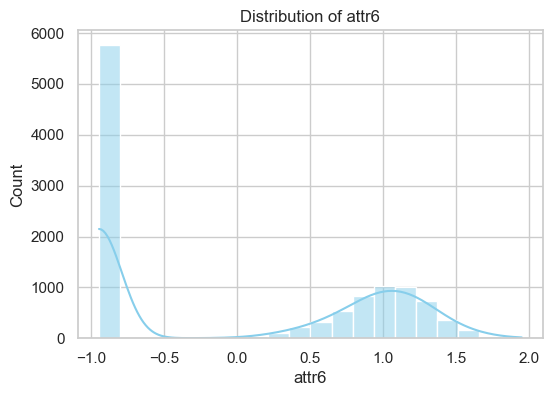

In [6]:
sns.set(style = "whitegrid")

continuous_features = ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
target = 'class'
#plot the historgrams for continous features 
for col in continuous_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

C:\Users\patrusgurung\AppData\Local\Temp\ipykernel_8700\4008742577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data= df, palette = "Set2" )


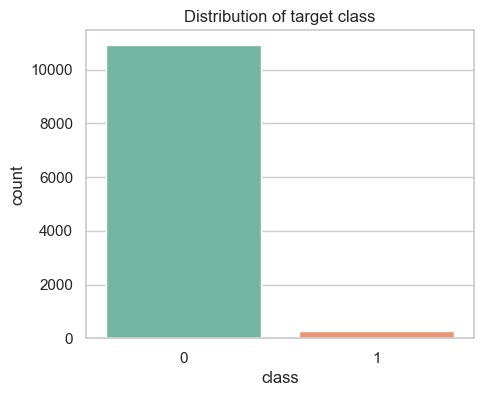

In [7]:
#plotting the target distrbution 
plt.figure(figsize=(5,4))
sns.countplot(x=target, data= df, palette = "Set2" )
plt.title('Distribution of target class')
plt.xlabel("class")
plt.ylabel("count")
plt.show()

#TASK b Spliting data into training and test set and ColumnTranfoermer and encoding pipeline with categorical and numerical featues 

In [10]:
#defining the numerical and categorical features 
X = df.drop('class', axis =1)
y = df['class']

#identify numerical and categoricla columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_fetures = X.select_dtypes(include= ['object']).columns.tolist()
#spliting into training and testing data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}") 

Training samples: 8946, Test samples: 2237


In [11]:
#building Column transformer 
#datasets has no any categorical featires so i have not put the categoraical value 
numeric_features = X_train.columns.tolist()
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features)
    ]
)
#building the pipeline 
baseline_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier( random_state=42, n_jobs=-1))

])

#evaluatin the CV 5 fold 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use F1 score since dataset is imbalanced
baseline_scores = cross_val_score(
    baseline_pipeline, X_train, y_train, cv=cv, scoring='f1'
)

print("5-Fold CV F1 scores:", baseline_scores)
print("Mean F1 score:      ", baseline_scores.mean().round(4))
print("Std F1 score:       ", baseline_scores.std().round(4))

5-Fold CV F1 scores: [0.68571429 0.64615385 0.71875    0.63636364 0.66666667]
Mean F1 score:       0.6707
Std F1 score:        0.0294


## TASK c hyperparmeter tuning using grid search and visualization 


In [12]:
#hyperparameter 
param_grid = {
    'classifier__n_estimators' : [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2,5],
    'classifier__min_samples_leaf': [1,2]
}
#Grid Search 
grid_search = GridSearchCV(
    baseline_pipeline,
    param_grid,
    cv=cv,
    scoring = 'f1',
    n_jobs = -1
)


grid_search.fit(X_train, y_train)

print("Best F1 score (tuned)  :", round(grid_search.best_score_, 4))
print("Best F1 score (baseline):", round(baseline_scores.mean(), 4))
print("Best hyperparameters   :", grid_search.best_params_)



Best F1 score (tuned)  : 0.6707
Best F1 score (baseline): 0.6707
Best hyperparameters   : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


No the result didnt improve it showed the same result of F1 score 0.6707.

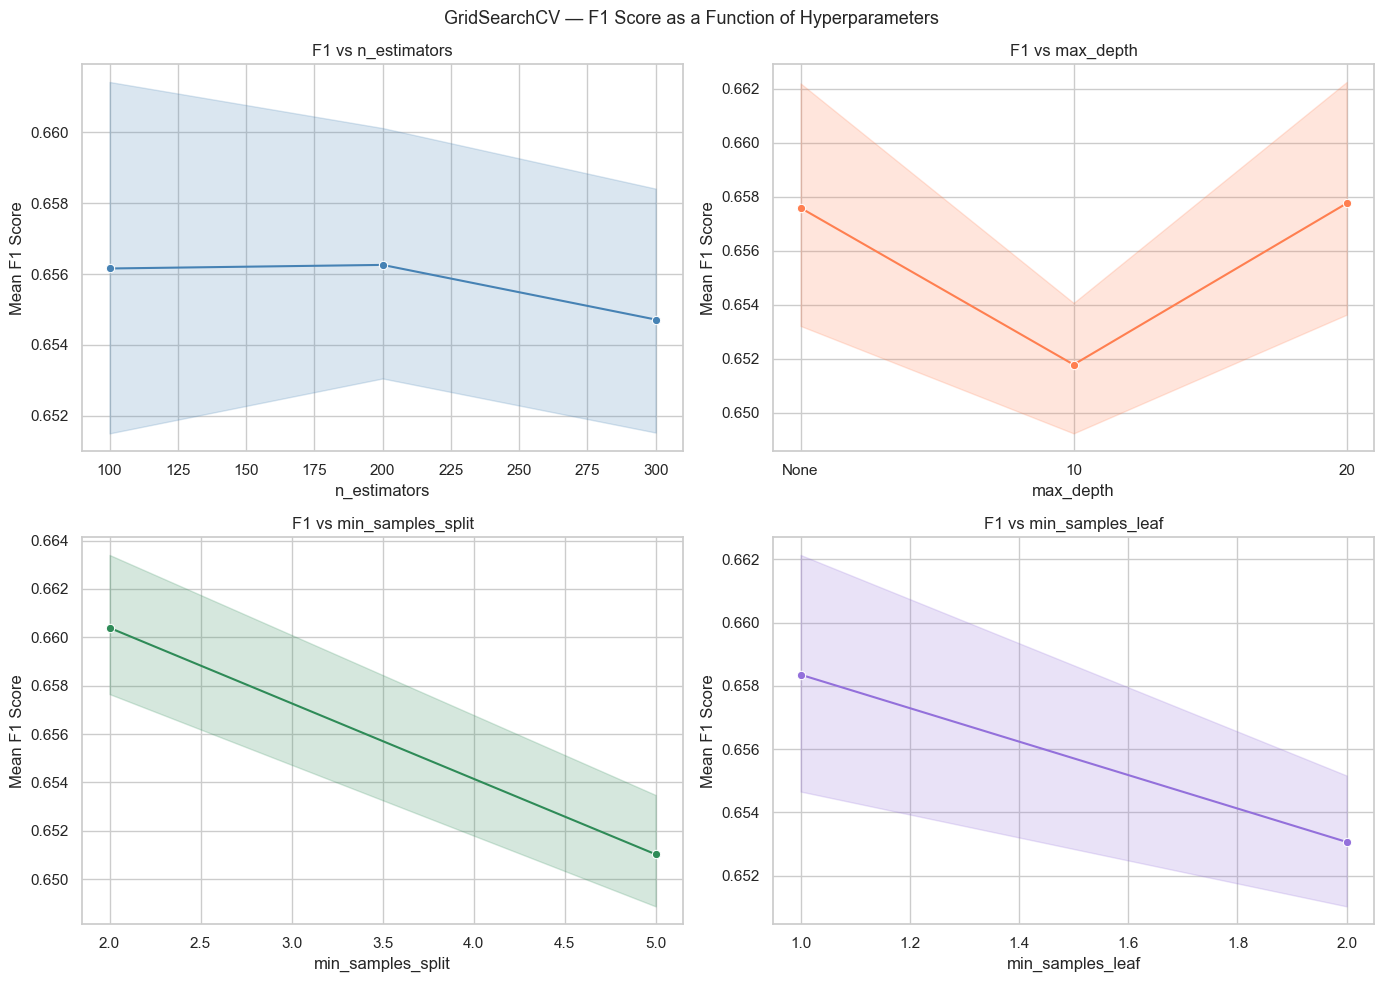

In [13]:
# Visualization 2 — F1 as a function of hyperparameters
# =============================================================================
results = pd.DataFrame(grid_search.cv_results_)

# convert None to string for plotting
results['param_classifier__max_depth'] = results[
    'param_classifier__max_depth'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — F1 vs n_estimators
sns.lineplot(
    data    = results,
    x       = 'param_classifier__n_estimators',
    y       = 'mean_test_score',
    marker  = 'o',
    color   = 'steelblue',
    ax      = axes[0, 0]
)
axes[0, 0].set_title("F1 vs n_estimators")
axes[0, 0].set_xlabel("n_estimators")
axes[0, 0].set_ylabel("Mean F1 Score")

# Plot 2 — F1 vs max_depth
sns.lineplot(
    data    = results,
    x       = 'param_classifier__max_depth',
    y       = 'mean_test_score',
    marker  = 'o',
    color   = 'coral',
    ax      = axes[0, 1]
)
axes[0, 1].set_title("F1 vs max_depth")
axes[0, 1].set_xlabel("max_depth")
axes[0, 1].set_ylabel("Mean F1 Score")

# Plot 3 — F1 vs min_samples_split
sns.lineplot(
    data    = results,
    x       = 'param_classifier__min_samples_split',
    y       = 'mean_test_score',
    marker  = 'o',
    color   = 'seagreen',
    ax      = axes[1, 0]
)
axes[1, 0].set_title("F1 vs min_samples_split")
axes[1, 0].set_xlabel("min_samples_split")
axes[1, 0].set_ylabel("Mean F1 Score")

# Plot 4 — F1 vs min_samples_leaf
sns.lineplot(
    data    = results,
    x       = 'param_classifier__min_samples_leaf',
    y       = 'mean_test_score',
    marker  = 'o',
    color   = 'mediumpurple',
    ax      = axes[1, 1]
)
axes[1, 1].set_title("F1 vs min_samples_leaf")
axes[1, 1].set_xlabel("min_samples_leaf")
axes[1, 1].set_ylabel("Mean F1 Score")

plt.suptitle("GridSearchCV — F1 Score as a Function of Hyperparameters", fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_strat = GridSearchCV(
    baseline_pipeline,
    param_grid,
    cv=cv_strat,
    scoring='f1'
)

grid_strat.fit(X_train, y_train)

print("StratifiedKFold Best Params:", grid_strat.best_params_)
print("StratifiedKFold Best F1:", grid_strat.best_score_)

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_kfold = GridSearchCV(
    baseline_pipeline,
    param_grid,
    cv=cv_kfold,
    scoring='f1'
)

grid_kfold.fit(X_train, y_train)

print("\nKFold Best Params:", grid_kfold.best_params_)
print("KFold Best F1:", grid_kfold.best_score_)

for seed in [0, 10, 42]:
    cv_k = KFold(n_splits=5, shuffle=True, random_state=seed)

    grid = GridSearchCV(
        baseline_pipeline,
        param_grid,
        cv=cv_k,
        scoring='f1'
    )

    grid.fit(X_train, y_train)

    print(f"\nSeed = {seed}")
    print("Best Params:", grid.best_params_)
    print("Best F1:", grid.best_score_)

    
for seed in [0, 42, 99]:
    
    X_train2, X_test2, y_train2, y_test2 = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    grid = GridSearchCV(
        baseline_pipeline,
        param_grid,
        cv=cv_strat,
        scoring='f1'
    )

    grid.fit(X_train2, y_train2)

    print(f"\nSplit Seed = {seed}")
    print("Best Params:", grid.best_params_)
    print("Best F1:", round(grid.best_score_, 4))

StratifiedKFold Best Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
StratifiedKFold Best F1: 0.6707296869796869

KFold Best Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
KFold Best F1: 0.6743411210212015

Seed = 0
Best Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Best F1: 0.6654721284666507

Seed = 10
Best Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best F1: 0.6714759148315537

Seed = 42
Best Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best F1: 0.6743411210212015

Split Seed = 0
Best Params: {'classif

Two random seeds are used because randomness occurs at two stages: data splitting and cross-validation. The train-test split seed controls how the dataset is divided into training and testing sets, while the cross-validation seed controls how the training data is further split into folds. Using both ensures reproducibility and allows analysis of model stability.

## Task (d): Effect of Cross-Validation Strategy and Randomness

###  Effect of Changing Cross-Validation Strategy

When comparing **StratifiedKFold** and **KFold**, the selected hyperparameters are different.

- **StratifiedKFold Best Params:**
  - n_estimators = 100  
  - min_samples_split = 2  

- **KFold Best Params:**
  - n_estimators = 200  
  - min_samples_split = 5  

This difference occurs because **StratifiedKFold preserves class distribution** in each fold, while **KFold does not**. Since the dataset is highly imbalanced, this leads to different model behavior and parameter selection.

---

###  Performance Comparison

- **StratifiedKFold F1 Score:** 0.6707  
- **KFold F1 Score:** 0.6743  

Although KFold shows a slightly higher F1 score, this result may not be reliable because it does not maintain class balance across folds.

---

###  Effect of Changing KFold Random Seed

Changing the random seed in KFold results in different hyperparameters and F1 scores:

- Seed = 0 → F1 = 0.6655 (different parameters)  
- Seed = 10 → F1 = 0.6715  
- Seed = 42 → F1 = 0.6743  

This shows that KFold is **sensitive to randomness**, and the selected parameters are not stable.

---

###  Effect of Changing Train-Test Split

Changing the random state of the train-test split also affects both performance and selected parameters:

- Seed = 0 → F1 = 0.6478 (lowest performance)  
- Seed = 42 → F1 = 0.6707  
- Seed = 99 → F1 = 0.6643  

This indicates that model performance depends on how the data is split, especially in imbalanced datasets.

---

###  Final Conclusion

- **StratifiedKFold is more stable and reliable** because it maintains class distribution across folds.  
- **KFold is more sensitive to randomness** and produces less consistent results.  
- Both cross-validation and train-test splitting introduce variability, highlighting the importance of careful evaluation.

---

###  Key Insight

The variability observed suggests that model evaluation should consider multiple runs or use stratified methods to ensure robustness.

### TASKE 

In [21]:
#task e Weighted Random forest with Stratified 5 fold CV 
#weighted pipeline 
weighted_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features)
    ])),
    ('classfier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
weighted_scores= cross_val_score(
    weighted_pipeline,X_train, y_train, cv=cv, scoring='f1'
)
print("Weighted RF — 5-Fold CV F1 scores:", weighted_scores)
print("Weighted RF — Mean F1            :", round(weighted_scores.mean(), 4))
print("Baseline RF — Mean F1            :", round(baseline_scores.mean(), 4))
print(f"Improvement                      : {weighted_scores.mean() - baseline_scores.mean():+.4f}")

Weighted RF — 5-Fold CV F1 scores: [0.59701493 0.64615385 0.61290323 0.63636364 0.625     ]
Weighted RF — Mean F1            : 0.6235
Baseline RF — Mean F1            : 0.6707
Improvement                      : -0.0472


## Evaluation of Weighted Random Forest with Stratified 5-Fold CV

The weighted Random Forest classifier achieved the following performance:

- **Weighted RF Mean F1-score:** 0.6235  
- **Baseline RF Mean F1-score:** 0.6707  
- **Improvement:** -0.0472  

The weighted model performs worse than the baseline model, as indicated by the lower mean F1-score and negative improvement. Therefore, applying class weighting in this case does not improve performance under stratified 5-fold cross-validation. The baseline Random Forest remains the better-performing model for this dataset.

### TASkf

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. SMOTE Pipeline ---
# ImbPipeline is used instead of Pipeline so SMOTE is applied
# only on training folds, not validation folds (prevents data leakage)
smote_pipeline = ImbPipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features)
    ])),
    ('smote',      SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

smote_scores = cross_val_score(
    smote_pipeline, X_train, y_train, cv=cv, scoring='f1'
)

print("SMOTE RF — 5-Fold CV F1 scores:", smote_scores)
print("SMOTE RF — Mean F1            :", round(smote_scores.mean(), 4))

#2 Random Undersampling Pipeline
under_pipeline = ImbPipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features)
    ])),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('classifier',  RandomForestClassifier(random_state=42, n_jobs=-1))
])
under_scores= cross_val_score(
    under_pipeline,X_train, y_train
, cv=cv, scoring='f1')

print("\nUndersampling RF — 5-Fold CV F1 scores:", under_scores)
print("Undersampling RF — Mean F1            :", round(under_scores.mean(), 4))

SMOTE RF — 5-Fold CV F1 scores: [0.61261261 0.55670103 0.65979381 0.5625     0.62626263]
SMOTE RF — Mean F1            : 0.6036

Undersampling RF — 5-Fold CV F1 scores: [0.33928571 0.3125     0.30452675 0.30088496 0.31818182]
Undersampling RF — Mean F1            : 0.3151


## Evaluation of SMOTE and Random Undersampling with Stratified 5-Fold CV

Two resampling techniques were evaluated using stratified 5-fold cross-validation with F1-score as the performance metric.

### 🔹 SMOTE (Synthetic Minority Over-sampling Technique)
- SMOTE generated synthetic samples for the minority class within each training fold.
- This helps balance the dataset without removing majority class information.

**Results:**
- SMOTE RF Mean F1-score: **0.6036**

### 🔹 Random Undersampling
- Random undersampling reduced the majority class by randomly removing samples.
- This can lead to loss of important information from the majority class.

**Results:**
- Undersampling RF Mean F1-score: **0.3151**

###  Conclusion
SMOTE significantly outperforms random undersampling in this case.

- SMOTE RF achieves a much higher mean F1-score (0.6036) compared to undersampling (0.3151).
- This indicates that generating synthetic minority samples is more effective than removing majority class samples for this dataset.
- Random undersampling likely degrades performance due to loss of useful training information.

Overall, SMOTE provides the better balance between class representation and model performance.

### TASK G 

In [25]:
# Function to compute metrics
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    # F1 Score
    f1 = f1_score(y_test, y_pred)
    
    # Error Rate
    error_rate = 1 - accuracy_score(y_test, y_pred)
    
    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Sensitivity (Recall / TPR)
    sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0
    
    # Specificity (TNR)
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    
    # G-Mean
    g_mean = np.sqrt(sensitivity * specificity)
    
    return {
        "Error Rate": error_rate,
        "F1 Score": f1,
        "G-Mean": g_mean
    }


# Example usage for multiple models
models = {
    "Baseline RF": baseline_pipeline,
    "Weighted RF": weighted_pipeline,
    "SMOTE RF": smote_pipeline,
    "Undersampling RF": under_pipeline
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    results[name] = metrics

# Print results
for name, metrics in results.items():
    print(f"\n{name}")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")


Baseline RF
Error Rate: 0.0139
F1 Score: 0.6173
G-Mean: 0.6927

Weighted RF
Error Rate: 0.0139
F1 Score: 0.6173
G-Mean: 0.6927

SMOTE RF
Error Rate: 0.0165
F1 Score: 0.7040
G-Mean: 0.9137

Undersampling RF
Error Rate: 0.0715
F1 Score: 0.3846
G-Mean: 0.9445


## Evaluation of Models and Explanation of Undersampling Performance

The models were evaluated using Error Rate, F1 Score, and G-Mean.

###  Results Summary

| Model                        | Error Rate | F1 Score | G-Mean |
|-----------------------------|-----------|----------|--------|
| Baseline Random Forest      | 0.0139    | 0.6173   | 0.6927 |
| Weighted Random Forest      | 0.0139    | 0.6173   | 0.6927 |
| SMOTE Random Forest         | 0.0165    | 0.7040   | 0.9137 |
| Undersampling Random Forest | 0.0715    | 0.3846   | 0.9445 |



### Observations
 The SMOTE Random Forest performs best overall, achieving the highest F1-score (0.7040) and a strong G-Mean (0.9137), indicating that the model effectively learns patterns from both the majority and minority classes by generating synthetic samples for the minority class without losing majority class information. The baseline and weighted Random Forest models perform similarly, with the same error rate (0.0139) and F1-score (0.6173), suggesting that class weighting does not significantly improve the model’s ability to handle the imbalance between majority and minority classes in this case.

In contrast, the undersampling Random Forest achieves a very high G-Mean (0.9445), indicating a balance between sensitivity  and specificity. However, it has a low F1-score (0.3846) and a high error rate (0.0715) because undersampling removes a large portion of the majority class data. This reduction limits the model’s ability to learn important patterns from the majority class, leading to poorer overall predictive performance despite the apparent balance between majority and minority class classification.

### TASK H

In [26]:
# optimal model is the smote pipline 
model2 = smote_pipeline
model2.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


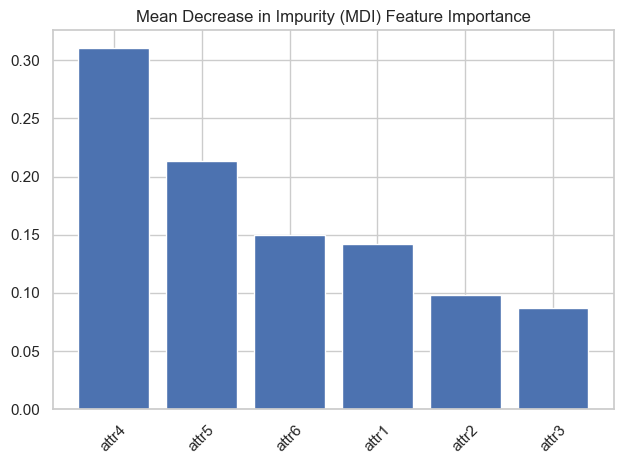

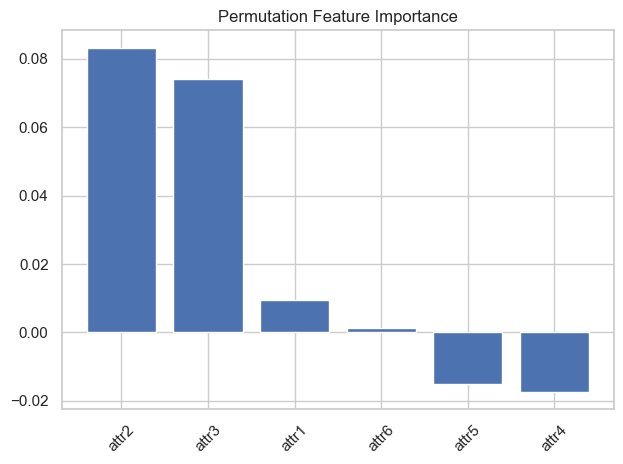

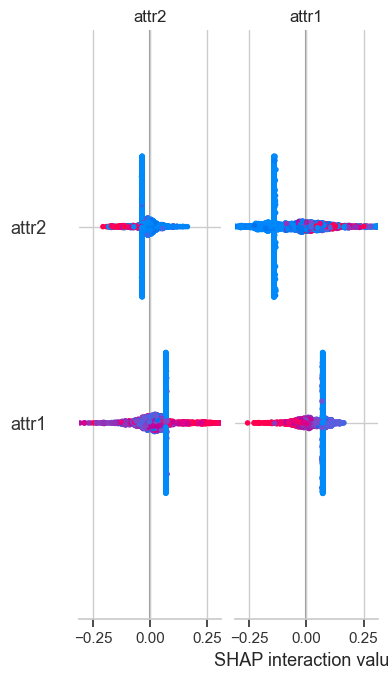

In [30]:
# Get feature names after preprocessing
feature_names = numeric_features 
# 1. Mean Decrease in Impurity (MDI)

rf = model.named_steps['classifier']

mdi_importances = rf.feature_importances_

mdi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mdi_importances
}).sort_values(by='importance', ascending=False)

# Plot MDI
plt.figure()
plt.bar(mdi_df['feature'], mdi_df['importance'])
plt.xticks(rotation=45)
plt.title("Mean Decrease in Impurity (MDI) Feature Importance")
plt.tight_layout()
plt.show()

# 2. Permutation Feature Importance
perm_result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, scoring='f1'
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_result.importances_mean
}).sort_values(by='importance', ascending=False)

# Plot Permutation Importance
plt.figure()
plt.bar(perm_df['feature'], perm_df['importance'])
plt.xticks(rotation=45)
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

# 3. SHAP Feature Importance
# SHAP explanation
explainer = shap.TreeExplainer(rf)

X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

shap_values = explainer.shap_values(X_test_transformed)

# Check if shap_values is a list (older SHAP behavior)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]  # class 1
else:
    shap_values_to_plot = shap_values

# Plot summary
shap.summary_plot(shap_values_to_plot, X_test_transformed, feature_names=feature_names)
